<a href="https://colab.research.google.com/github/prameela-rani-patnaik/Student_Performance_Analysis/blob/main/M3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv(r"student_exam_performance_dataset.csv")

In [ ]:
df.shape

(10000, 23)

In [ ]:
# Create target
df['pass_fail'] = (df['math_score'] >= 40).astype(int)
X = df[[
    'study_hours_per_day',
    'attendance_rate',
    'sleep_hours',
    'previous_gpa'
]]
y = df['pass_fail']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
new_data = pd.DataFrame({
    'study_hours_per_day': [6],
    'attendance_rate':[45],
    'sleep_hours':[6],
    'previous_gpa':[9.8]
})

new_data_scaled = scaler.transform(new_data)

print(model.predict(new_data_scaled))
print(model.predict_proba(new_data_scaled))

[1]
[[1.76525461e-13 1.00000000e+00]]


In [ ]:
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 451  319]
 [ 177 2053]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.59      0.65       770
           1       0.87      0.92      0.89      2230

    accuracy                           0.83      3000
   macro avg       0.79      0.75      0.77      3000
weighted avg       0.83      0.83      0.83      3000



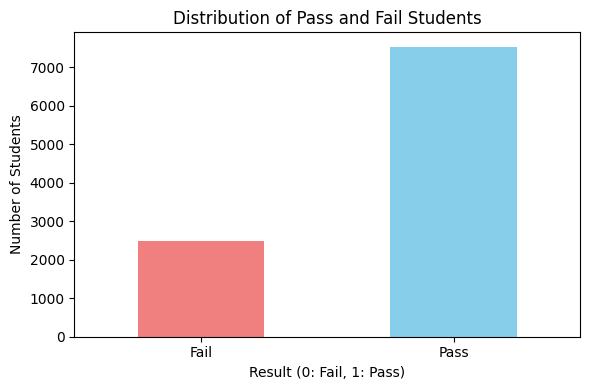

In [60]:
# .sort_index() ensures 0 comes first, then 1
pass_fail_counts = df['pass_fail'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
# Flipped the color order to match 0 (Fail -> lightcoral) and 1 (Pass -> skyblue) if desired
pass_fail_counts.plot(kind='bar', color=['lightcoral', 'skyblue'])

plt.title('Distribution of Pass and Fail Students')
plt.xlabel('Result (0: Fail, 1: Pass)')
plt.ylabel('Number of Students')
plt.xticks(ticks=[0, 1], labels=['Fail', 'Pass'], rotation=0)
plt.tight_layout()
plt.show()

In [61]:
from sklearn.metrics import accuracy_score
y_prob = model.predict_proba(X_test_scaled)

# Extract probabilities for 'fail' (class 0) and 'pass' (class 1)
prob_fail = y_prob[:, 0]
prob_pass = y_prob[:, 1]

print(prob_fail)
print(prob_pass)

[0.06194107 0.16103671 0.42095297 ... 0.0809988  0.24001048 0.15701803]
[0.93805893 0.83896329 0.57904703 ... 0.9190012  0.75998952 0.84298197]
